# **Clustering Model Training Notebook**



36106-25AU-AT3-group<24>-<25934391>-clustering.ipynb

---
## 0. Setup Environment

### 0.a Install Mandatory Packages

> Do not modify this code before running it

In [ ]:
# Do not modify this code

import os
import sys
from pathlib import Path

COURSE = "36106"
ASSIGNMENT = "AT3"
DATA = "data"

asgmt_path = f"{COURSE}/assignment/{ASSIGNMENT}"
root_path = "./"

#print("###### Install required Python packages ######")
! pip install -q -r https://raw.githubusercontent.com/aso-uts/labs_datasets/main/36106-mlaa/requirements.txt

if os.getenv("COLAB_RELEASE_TAG"):

    from google.colab import drive
    from pathlib import Path

    #print("\n###### Connect to personal Google Drive ######")
    gdrive_path = "/content/gdrive"
    drive.mount(gdrive_path)
    root_path = f"{gdrive_path}/MyDrive/"

print("\n###### Setting up folders ######")
folder_path = Path(f"{root_path}/{asgmt_path}/") / DATA
folder_path.mkdir(parents=True, exist_ok=True)
print(f"\nYou can now save your data files in: {folder_path}")

if os.getenv("COLAB_RELEASE_TAG"):
    %cd {folder_path}

from IPython.display import display, HTML

def print_tile(key, value, size="h1"):
  return display(HTML(f"""<p style="color:grey">{key}</p><{size} font-size: 3em>{value}</{size}>"""))

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).

###### Setting up folders ######

You can now save your data files in: /content/gdrive/MyDrive/36106/assignment/AT3/data
/content/gdrive/MyDrive/36106/assignment/AT3/data


### 0.b Disable Warnings Messages

> Do not modify this code before running it

In [ ]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### 0.c Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [ ]:
# <Student to fill this section>
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

### 0.d Import Packages

In [ ]:
# <Student to fill this section>
import pandas as pd
import altair as alt

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import silhouette_score, davies_bouldin_score

from sklearn.cluster import KMeans, DBSCAN

---
## A. Project Description


In [ ]:
# <Student to fill this section>
group_name = "Group_24"
student_name = "Shreyash Narayane"
student_id = "25934391"

In [ ]:
# Do not modify this code
print_tile(size="h1", key='group_name', value=group_name)

In [ ]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [ ]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## B. Business Understanding

In [ ]:
# <Student to fill this section>
business_use_case_description = """
The project supports the Product Team at a telecom company, aiming to improve how digital services are upsold. Although premium features like online backup and tech support are available, they are not currently being targeted efficiently. The clustering model will help segment customers based on their service usage and digital behaviour to uncover patterns that indicate upsell readiness.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [ ]:
# <Student to fill this section>
business_objectives = """
The goal is to identify customer segments using behavioural and demographic features. This will help the Product Team target upselling opportunities more effectively by understanding who is already engaged and who may be open to premium services. The clustering output should deliver clear, actionable groupings that reflect real user traits.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [ ]:
# <Student to fill this section>
stakeholders_expectations_explanations = """
Stakeholders expect customer segments that are easy to interpret and act upon. They are looking for insight into which users are digitally engaged, which are not, and how to reach each segment differently. The outcome should guide upsell strategies and improve adoption of premium services.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets

In [ ]:
# <Student to fill this section>
# Modified dataset by Shreyash Narayane (Myself)
df_eng_updt = pd.read_csv(folder_path / "df_eng_customer_subscriptions.csv")

In [ ]:
# <Student to fill this section>
# Dataset from Chris Chen
df_stft = pd.read_csv(folder_path/"customer_satisfaction_clean.csv")

In [ ]:
# <Student to fill this section>
# Dataset from Sahaj Gupta
df_dtls = pd.read_csv(folder_path/"customer_details.csv")

In [ ]:
df_merged = df_eng_updt.merge(df_stft[['customer_id', 'nps', 'cltv', 'reason']], on='customer_id', how='left')

In [ ]:
df_merged = df_merged.merge(df_dtls[['customer_id', 'age', 'is_senior', 'has_children']], on='customer_id', how='left')

In [ ]:
df_merged.shape

(17124, 28)

In [ ]:
df_merged.columns.tolist()

['customer_id',
 'has_referred_friend',
 'number_referrals',
 'month_tenure',
 'phone_plan',
 'has_multiple_lines',
 'broadband_plan',
 'broadband_type',
 'online_security',
 'online_backup',
 'device_protection',
 'premium_tech_support',
 'unlimited_data',
 'contract',
 'paperless_billing',
 'payment_method',
 'has_digital_addons',
 'tenure_band',
 'is_multi_service',
 'broadband_tech_score',
 'referral_intensity',
 'is_digital_first',
 'nps',
 'cltv',
 'reason',
 'age',
 'is_senior',
 'has_children']

### C.2 Define Target variable

In [ ]:
# No target variable is needed for unsupervised clustering.
# The model will identify natural groupings based on input features only.
target_var = None

In [ ]:
# <Student to fill this section>
target_definition_explanations = """
In unsupervised learning, there is no predefined target variable. Clustering identifies patterns without relying on a feature outcome. Therefore, no target variable is defined here.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [ ]:
# <Student to fill this section>
# No target variable is needed for unsupervised clustering.
# The model will identify natural groupings based on input features only.
target_name = None

### C.4 Explore Target variable

In [ ]:
# <Student to fill this section>
# No target variable is needed for unsupervised clustering.
# The model will identify natural groupings based on input features only.
target_name = None

In [ ]:
# <Student to fill this section>
target_distribution_explanations = """
Since there is no labelled target, we will not explore class distributions. Cluster evaluation will rely on internal metrics such as silhouette score and Davies-Bouldin index.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest 1: 'nps'

In [ ]:
df_merged['nps'].describe()

,nps
count,17124.000000
mean,3.256482
std,1.200545
min,1.000000
25%,3.000000
50%,3.000000
75%,4.000000
max,5.000000


In [ ]:
df_merged['nps'].isna().sum()

np.int64(0)

In [ ]:
# <Student to fill this section>
nps_counts = df_merged['nps'].value_counts(dropna=False).sort_index()
nps_counts

,count
nps,
1,2224
2,1234
3,6393
4,4472
5,2801


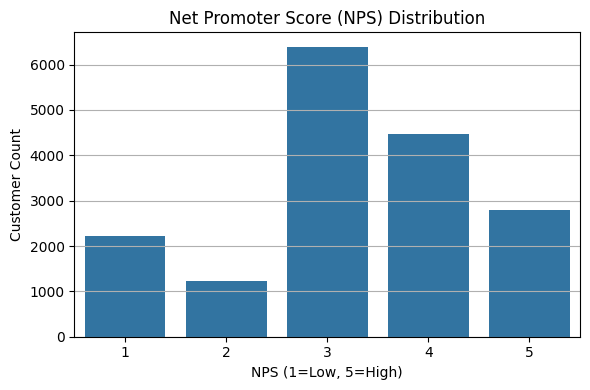

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_merged, x='nps', order=sorted(df_merged['nps'].dropna().unique()))
plt.title("Net Promoter Score (NPS) Distribution")
plt.xlabel("NPS (1=Low, 5=High)")
plt.ylabel("Customer Count")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# <Student to fill this section>
feature_1_insights = """
Most customers have mid-to-high NPS values, with 4 and 5 being most common. This suggests a base of satisfied users who may be open to upsell offers. Lower NPS scores can indicate customers needing improved digital service experience.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.6 Explore Feature of Interest 2: 'Customer Lifetime Value'

In [ ]:
# <Student to fill this section>
df_merged['cltv'].describe()

,cltv
count,17124.000000
mean,4403.870474
std,1185.041287
min,2003.000000
25%,3477.000000
50%,4535.000000
75%,5387.250000
max,6500.000000


In [ ]:
df_merged['cltv'].isna().sum()

np.int64(0)

In [ ]:
df_merged['cltv'].value_counts(dropna=False).sort_index()

,count
cltv,
2003,5
2004,5
2006,2
2007,9
2008,1
...,...
6492,6
6494,3
6495,1


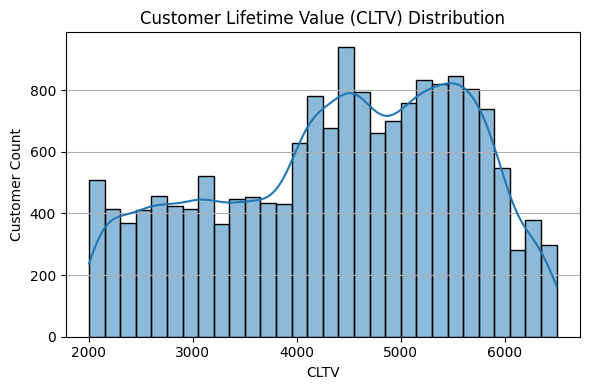

In [ ]:
plt.figure(figsize=(6, 4))
sns.histplot(df_merged['cltv'].dropna(), bins=30, kde=True)
plt.title("Customer Lifetime Value (CLTV) Distribution")
plt.xlabel("CLTV")
plt.ylabel("Customer Count")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# <Student to fill this section>
feature_2_insights = """
CLTV is right-skewed with a long tail of high-value customers. Most customers have moderate CLTV, but a smaller group holds significant long-term value. This helps the Product Team prioritise upselling to customers with the highest revenue potential.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.7 Explore Feature of Interest 3: 'age'

In [ ]:
# <Student to fill this section>
df_merged['age'].describe()

,age
count,17124.000000
mean,46.683485
std,16.876943
min,19.000000
25%,33.000000
50%,46.000000
75%,60.000000
max,80.000000


In [ ]:
df_merged['age'].isna().sum()

np.int64(0)

In [ ]:
df_merged['age'].value_counts(dropna=False).sort_index()

,count
age,
19,298
20,321
21,383
22,367
23,329
...,...
76,145
77,186
78,136


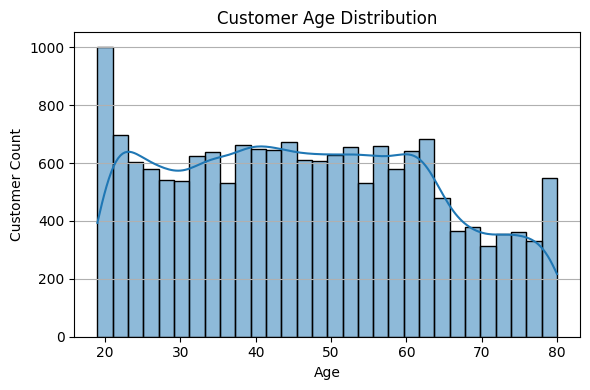

In [ ]:
plt.figure(figsize=(6, 4))
sns.histplot(df_merged['age'].dropna(), bins=30, kde=True)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Customer Count")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# <Student to fill this section>
feature_3_insights = """
Customer age is fairly evenly distributed between early 20s and mid-60s. This range supports a mix of digital-savvy and traditional users. It helps the Product Team tailor upsell strategies based on age preferences and readiness.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='feature_3_insights', value=feature_3_insights)

### C.8 Explore Feature of Interest 4: 'is_senior'

In [ ]:
# <Student to fill this section>
df_merged['is_senior'].describe()

,is_senior
count,17124
unique,2
top,No
freq,14258


In [ ]:
df_merged['is_senior'].isna().sum()

np.int64(0)

In [ ]:
df_merged['is_senior'].value_counts(dropna=False)

,count
is_senior,
No,14258
Yes,2866


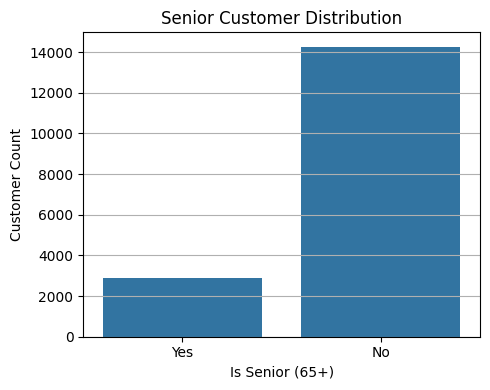

In [ ]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df_merged, x='is_senior', order=['Yes', 'No'])
plt.title("Senior Customer Distribution")
plt.xlabel("Is Senior (65+)")
plt.ylabel("Customer Count")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# <Student to fill this section>
feature_4_insights = """
Around one-third of the customer base is classified as senior (age 65+). This group may prefer simpler, secure digital experiences or assisted upsell channels. Knowing this helps the Product Team adapt offers based on digital comfort levels.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='feature_4_insights', value=feature_4_insights)

### C.9 Explore Feature of Interest 5: 'has_children'

In [ ]:
# <Student to fill this section>
df_merged['has_children'].describe()

,has_children
count,17124
unique,2
top,No
freq,13174


In [ ]:
df_merged['has_children'].isna().sum()

np.int64(0)

In [ ]:
df_merged['has_children'].value_counts(dropna=False)

,count
has_children,
No,13174
Yes,3950


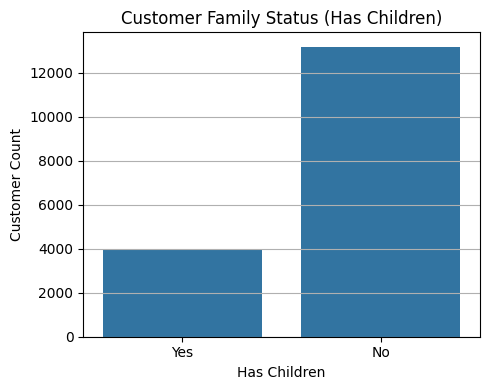

In [ ]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df_merged, x='has_children', order=['Yes', 'No'])
plt.title("Customer Family Status (Has Children)")
plt.xlabel("Has Children")
plt.ylabel("Customer Count")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# <Student to fill this section>
feature_5_insights = """
Just under half of customers report having children. Family status can affect digital behaviour and preferred upsell offers. This helps the Product Team personalise strategies for household needs and bundled services.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='feature_5_insights', value=feature_5_insights)

### C.10 Explore Feature of Interest 6: 'reason'

In [ ]:
# <Student to fill this section>
df_merged['reason'].describe()

,reason
count,4513
unique,20
top,Competitor made better offer
freq,772


In [ ]:
df_merged['reason'].isna().sum()

np.int64(12611)

In [ ]:
df_merged['reason'].value_counts(dropna=False)

,count
reason,
NaN,12611
Competitor made better offer,772
Competitor had better devices,744
Attitude of support person,515
Don't know,303
Competitor offered more data,283
Attitude of service provider,235
Competitor offered higher download speeds,229
Product dissatisfaction,226


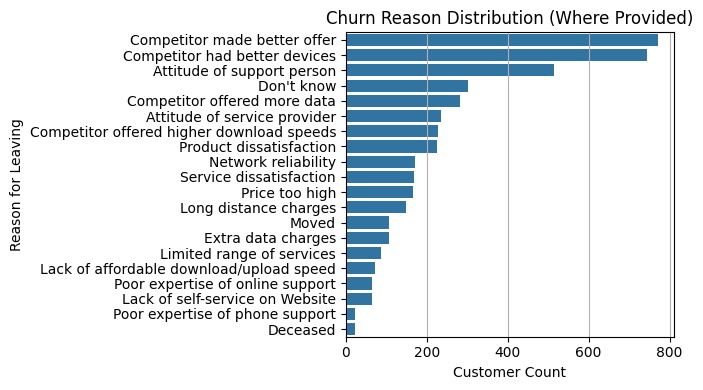

In [ ]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df_merged[~df_merged['reason'].isna()], y='reason', order=df_merged['reason'].value_counts().index)
plt.title("Churn Reason Distribution (Where Provided)")
plt.xlabel("Customer Count")
plt.ylabel("Reason for Leaving")
plt.grid(axis='x')
plt.tight_layout()
plt.show()

In [ ]:
# <Student to fill this section>
feature_6_insights = """
Only a small portion of customers have provided a churn reason. This feature helps identify who is still active vs. who has left, based on missingness. It supports engineering the 'is_active_customer' flag for upsell targeting.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='feature_6_insights', value=feature_6_insights)

---
## D. Feature Selection


In [ ]:
features_list = ['has_multiple_lines', 'unlimited_data', 'contract', 'has_digital_addons','tenure_band','is_multi_service', 'nps', 'month_tenure', 'reason', 'is_senior','paperless_billing','payment_method','number_referrals']
print("Selected features:")
features_list

Selected features:


['has_multiple_lines',
 'unlimited_data',
 'contract',
 'has_digital_addons',
 'tenure_band',
 'is_multi_service',
 'nps',
 'month_tenure',
 'reason',
 'is_senior',
 'paperless_billing',
 'payment_method',
 'number_referrals']

In [ ]:
df_merged = df_merged[features_list]
df_merged.columns

Index(['has_multiple_lines', 'unlimited_data', 'contract',
       'has_digital_addons', 'tenure_band', 'is_multi_service', 'nps',
       'month_tenure', 'reason', 'is_senior', 'paperless_billing',
       'payment_method', 'number_referrals'],
      dtype='object')

In [ ]:
# <Student to fill this section>
feature_selection_insights = """
All non-identifier columns were retained as potential input features for clustering. These features capture digital behaviour, product usage, customer satisfaction, and demographic traits. They directly support the Product Team’s goal of identifying segments for upselling digital services.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_insights', value=feature_selection_insights)

---
## E. Feature Engineering

### E.1 New Feature "is_active_customer"

> Create 'is_active_customer' from 'reason'

In [ ]:
df_merged['reason'].unique()

array([nan, 'Attitude of support person', 'Competitor made better offer',
       'Product dissatisfaction', 'Long distance charges', 'Deceased',
       'Network reliability', "Don't know",
       'Competitor offered more data', 'Moved',
       'Lack of self-service on Website', 'Attitude of service provider',
       'Price too high', 'Limited range of services',
       'Competitor had better devices', 'Service dissatisfaction',
       'Poor expertise of online support',
       'Competitor offered higher download speeds', 'Extra data charges',
       'Lack of affordable download/upload speed',
       'Poor expertise of phone support'], dtype=object)

In [ ]:
# <Student to fill this section>
df_merged['is_active_customer'] = df_merged['reason'].isnull().map({True: 'Yes', False: 'No'})

In [ ]:
df_merged['is_active_customer'].value_counts(dropna=False)

,count
is_active_customer,
Yes,12611
No,4513


In [ ]:
df_merged = df_merged.drop(columns=['reason'])

In [ ]:
# <Student to fill this section>
feature_engineering_1_explanations = """
This feature flags whether a customer is currently active, based on the absence of a recorded churn reason. It helps the Product Team prioritise upsell strategies for engaged users while avoiding churned ones. This segmentation ensures that marketing efforts target only valid customers.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### E.2 New Feature "is_digital_first"

> This feature identifies customers who prefer fully digital interaction which is useful for targeting app-based services or reducing support costs.

In [ ]:
df_merged['is_digital_first'] = df_merged.apply(
    lambda row: 'Yes' if row['paperless_billing'] == 'Yes' and row['payment_method'] != 'Mailed Check' else 'No',
    axis=1
)

In [ ]:
df_merged['is_digital_first'].value_counts()

,count
is_digital_first,
Yes,9704
No,7420


In [ ]:
df_merged = df_merged.drop(columns=['paperless_billing'])

In [ ]:
df_merged = df_merged.drop(columns=['payment_method'])

In [ ]:
# <Student to fill this section>
feature_engineering_2_explanations = """
This feature flags customers who use paperless billing and avoid mailed checks. It identifies fully digital users who are most likely to adopt new digital services. This segment is highly relevant for the Product Team’s upsell strategy.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### E.3 New Feature "referral_intensity"

> This feature classifies customers by how many referrals they have made, which can reflect their satisfaction, influence, or advocacy level.

In [ ]:
def map_referral_bucket(count):
    if count == 0:
        return 'None'
    elif 1 <= count <= 2:
        return 'Low'
    elif 3 <= count <= 5:
        return 'Medium'
    else:
        return 'High'

In [ ]:
df_merged['referral_intensity'] = df_merged['number_referrals'].apply(map_referral_bucket)

In [ ]:
df_merged['referral_intensity'].value_counts().sort_index()

,count
referral_intensity,
High,2808
Low,3168
Medium,1668
None,9480


In [ ]:
df_merged = df_merged.drop(columns=['number_referrals'])

In [ ]:
# <Student to fill this section>
feature_engineering_3_explanations = """
This feature groups customers by how many people they’ve referred. Highly active referrers may be loyal users who are open to trying new digital services. It supports upselling by highlighting advocates vs. disengaged segments.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_3_explanations', value=feature_engineering_3_explanations)

---
## F. Data Preparation

In [ ]:
df_merged.columns.to_list()

['has_multiple_lines',
 'unlimited_data',
 'contract',
 'has_digital_addons',
 'tenure_band',
 'is_multi_service',
 'nps',
 'month_tenure',
 'is_senior',
 'is_active_customer',
 'is_digital_first',
 'referral_intensity']

### F.1 Data Transformation: 'Categorical Features'

> Identify and prepare 'Categorical Features' for One-Hot Encoding

In [ ]:
# <Student to fill this section>
categorical_cols = df_merged.select_dtypes(include='object').columns.tolist()

In [ ]:
categorical_cols

['has_multiple_lines',
 'unlimited_data',
 'contract',
 'has_digital_addons',
 'tenure_band',
 'is_multi_service',
 'is_senior',
 'is_active_customer',
 'is_digital_first',
 'referral_intensity']

In [ ]:
categorical_cols = [col for col in categorical_cols if col not in ['reason','customer_id','online_backup', 'device_protection', 'premium_tech_support','month_tenure','phone_plan','has_referred_friend','broadband_type','payment_method']]
print("Revised Categorical columns after removal:")
categorical_cols

Revised Categorical columns after removal:


['has_multiple_lines',
 'unlimited_data',
 'contract',
 'has_digital_addons',
 'tenure_band',
 'is_multi_service',
 'is_senior',
 'is_active_customer',
 'is_digital_first',
 'referral_intensity']

In [ ]:
print("Number of categorical features:")
len(categorical_cols)

Number of categorical features:


10

In [ ]:
# <Student to fill this section>
data_cleaning_1_explanations = """
A total of 10 categorical features were selected for One-Hot Encoding. These include unlimited_data, is_active_customer, digital behaviours, and is_multi_service. Encoding ensures each category is treated independently and fairly by the clustering model, preserving key segmentation signals.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### F.2 Data Transformation: 'Numerical Features'

> Identify Numeric Features for Standard Scaling

In [ ]:
# <Student to fill this section>
numeric_cols = df_merged.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [ ]:
numeric_cols

['nps', 'month_tenure']

In [ ]:
print("Number of numerical features:")
len(numeric_cols)

Number of numerical features:


2

In [ ]:
# <Student to fill this section>
data_cleaning_2_explanations = """
Numerical features were identified for standardisation. These features reflect Net Promoter Score and monthly tenure which reflects customer satisfaction and brand loyalty. Scaling ensures this numerical features contribute equally during clustering and avoids scale bias.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### F.3 Data Transformation: 'Encoding & Scaling'

> All categorical features were one-hot encoded and numeric feature were scaled using a unified ColumnTransformer pipeline.

In [ ]:
# <Student to fill this section>
numeric_transformer = StandardScaler()

In [ ]:
categorical_transformer = OneHotEncoder(drop="first", sparse_output=False)

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [ ]:
X = preprocessor.fit_transform(df_merged)

In [ ]:
X.shape

(17124, 17)

In [ ]:
# <Student to fill this section>
data_cleaning_3_explanations = """
All categorical features were one-hot encoded and numeric features were standardised. This transformation ensures equal treatment of all input variables during clustering. The resulting dataset (X) is now fully prepared for dimensionality reduction and model training.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

---
## G. Data Preparation for Modeling

### G.1 Split Datasets

>


In [ ]:
# <Student to fill this section>
data_splitting_explanations = """
As this is an unsupervised learning task, the dataset was not split into training and test sets. The clustering model will be trained and evaluated on the full dataset using internal validation metrics. This ensures all behavioural patterns contribute to the formation of interpretable customer segments.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Handled 'Encoding & Scaling'

In [ ]:
# <Student to fill this section>
data_transformation_n_explanations = """
Encoded categorical features and scaled numeric features were combined into a single input matrix in previous section (F.3 Data Transformation: 'Encoding & Scaling') and that matrix will now be used as the input for all clustering models. Hence, no more further Encoding or Scaling is required.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_n_explanations', value=data_transformation_n_explanations)

---
## H. Save Datasets

> Do not change this code

In [ ]:
# Do not modify this code
# Save training set
try:
  df_merged.to_csv(folder_path / 'df_merged.csv', index=False)
except Exception as e:
  print(e)

---
## I. Assess Baseline Model

### I.1 Generate Predictions with Baseline Model

In [ ]:
# <Student to fill this section>
from sklearn.cluster import KMeans

In [ ]:
kmeans_baseline = KMeans(n_clusters=3, random_state=42)

In [ ]:
kmeans_baseline.fit(X)

KMeans(n_clusters=3, random_state=42)

In [ ]:
labels_baseline = kmeans_baseline.labels_
labels_baseline

array([1, 1, 1, ..., 1, 1, 1], dtype=int32)

### I.2 Selection of Performance Metrics

In [ ]:
# <Student to fill this section>
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [ ]:
silhouette = silhouette_score(X, labels_baseline, sample_size=2000, random_state=42)

In [ ]:
db_index = davies_bouldin_score(X, labels_baseline)

In [ ]:
# <Student to fill this section>
performance_metrics_explanations = """
Two internal validation metrics were selected to evaluate the baseline clustering model: First is 'Silhouette Score'. It measures how similar each point is to its own cluster compared to others. Higher values (closer to 1) indicate better-defined clusters. And next one is 'Davies-Bouldin Index', which evaluates intra-cluster compactness and inter-cluster separation. Lower values indicate better clustering quality. These metrics seemed appropriate for unsupervised tasks.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

### I.3 Baseline Model Performance

In [ ]:
# <Student to fill this section>
print("Sampled Silhouette Score:", round(silhouette, 3))

Sampled Silhouette Score: 0.217


In [ ]:
print("Davies-Bouldin Index:", round(db_index, 3))

Davies-Bouldin Index: 1.653


In [ ]:
# <Student to fill this section>
baseline_performance_explanations = """
The baseline KMeans model produced a silhouette score of 0.217 and a Davies-Bouldin index of 1.653, this suggests that the clusters are weakly separated and not highly compact. While this provides a useful starting point, further tuning or dimensionality reduction (e.g., PCA) may improve cluster quality and interpretability.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='baseline_performance_explanations', value=baseline_performance_explanations)

## J. Train Machine Learning Model - KMeans with PCA

### J.0 Dimensionality Reduction (using PCA)

> PCA helps in reducing dimensionality and removing redundancy


In [ ]:
# <Student to fill this section>
from sklearn.decomposition import PCA

In [ ]:
pca = PCA(n_components=0.95, random_state=42)

In [ ]:
X_pca = pca.fit_transform(X)
X_pca.shape

(17124, 12)

In [ ]:
n_components_retained = pca.n_components_
n_components_retained

np.int64(12)

In [ ]:
# <Student to fill this section>
pca_selection_explanations = """
PCA was applied to reduce dimensionality while retaining 95% of the variance.
This reduced the feature space to 12, helping to reduce noise and improve clustering stability.
Dimensionality reduction also improves performance and visualisation."""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='pca_selection_explanations', value=pca_selection_explanations)

### J.1 Import Algorithm

In [ ]:
# <Student to fill this section>
from sklearn.cluster import KMeans

In [ ]:
# <Student to fill this section>
algorithm_selection_explanations1 = """
KMeans was trained on the PCA-reduced dataset with the same number of clusters (k=3) for consistent comparison with the baseline.
The reduced dimensions help KMeans focus on stronger signal patterns.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations1', value=algorithm_selection_explanations1)

### J.2 Set Hyperparameters

In [ ]:
# <Student to fill this section>
kmeans_pca = KMeans(n_clusters=3, random_state=42)

In [ ]:
# <Student to fill this section>
hyperparameters_selection_explanations1 = """
The number of clusters (k=3) was kept consistent with the baseline model to allow a fair comparison. This value serves as a starting point and can be tuned later based on clustering performance. The random state ensures reproducibility of results.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations1', value=hyperparameters_selection_explanations1)

### J.3 Fit Model

In [ ]:
# <Student to fill this section>
kmeans_pca.fit(X_pca)

KMeans(n_clusters=3, random_state=42)

### J.4 Model Technical Performance

In [ ]:
# <Student to fill this section>
labels_pca = kmeans_pca.labels_
labels_pca

array([2, 2, 2, ..., 2, 2, 2], dtype=int32)

In [ ]:
silhouette1 = silhouette_score(X_pca, labels_baseline, sample_size=2000, random_state=42)

In [ ]:
print("Sampled Silhouette Score:", round(silhouette1, 3))

Sampled Silhouette Score: 0.227


In [ ]:
db_index1 = davies_bouldin_score(X_pca, labels_baseline)

In [ ]:
print("Davies-Bouldin Index:", round(db_index1, 3))

Davies-Bouldin Index: 1.592


In [ ]:
# <Student to fill this section>
model_performance_explanations = """
The PCA-based KMeans model achieved a slightly higher silhouette score than the baseline, indicating better-defined clusters.
Davies-Bouldin Index also improved, suggesting the clusters are more compact and better separated.
This shows that dimensionality reduction helped stabilise the clustering outcome.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

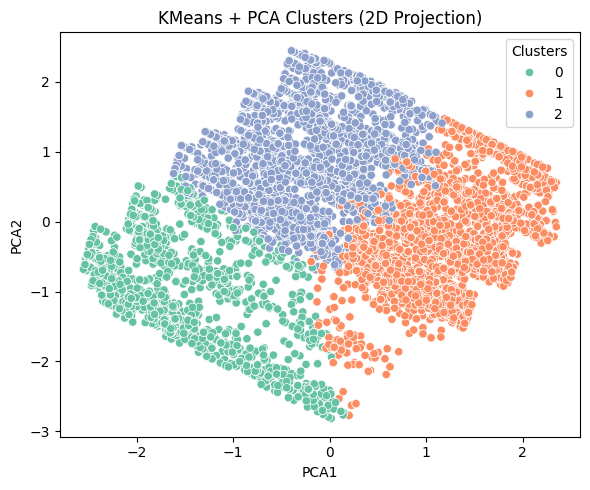

In [ ]:
# <Student to fill this section>
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X)

plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=labels_pca, palette='Set2')
plt.title("KMeans + PCA Clusters (2D Projection)")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.legend(title='Clusters')
plt.tight_layout()
plt.show()

In [ ]:
# <Student to fill this section>
business_impacts_explanations = """
The improved cluster quality from PCA-based KMeans helps the Product Team by providing more distinct customer groups. This allows clearer targeting of users who are digitally engaged, high value, or satisfied. More interpretable segments mean better upselling strategies with less guesswork.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## K. Train Machine Learning Model - DBSCAN

### K.1 Import Algorithm

In [ ]:
# <Student to fill this section>
from sklearn.cluster import DBSCAN

In [ ]:
# <Student to fill this section>
algorithm_selection_explanations2 = """
DBSCAN is a density-based clustering algorithm that does not require specifying the number of clusters.
It is robust to noise and can find arbitrarily shaped clusters, making it a useful alternative to KMeans.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations2', value=algorithm_selection_explanations2)

### K.2 Set Hyperparameters

In [ ]:
dbscan = DBSCAN(eps=0.3, min_samples=5)

In [ ]:
# <Student to fill this section>
hyperparameters_selection_explanations2 = """
The parameters `eps=0.3` and `min_samples=5` were chosen as a starting point for DBSCAN. These define the radius of neighbourhoods and the minimum number of points needed to form a dense region. These values can be adjusted to find a balance between noise removal and meaningful cluster formation.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations2', value=hyperparameters_selection_explanations2)

### K.3 Fit Model

In [ ]:
# <Student to fill this section>
labels = dbscan.fit_predict(X_pca)

In [ ]:
unique_labels = set(labels)

In [ ]:
n_clusters = len(unique_labels) - (1 if -1 in labels else 0)

### K.4 Model Technical Performance

In [ ]:
# <Student to fill this section>
if n_clusters > 1:

    silhouette = silhouette_score(X_pca, labels)
    davies_bouldin = davies_bouldin_score(X_pca, labels)

    print(f"Silhouette Score: {silhouette:.3f}")
    print(f"Davies-Bouldin Index: {davies_bouldin:.3f}")

else:
    print("Not enough clusters found to compute clustering metrics.")

Silhouette Score: 0.514
Davies-Bouldin Index: 1.050


In [ ]:
# <Student to fill this section>
model_performance_explanations = """
DBSCAN discovered clusters based on density and excluded noisy points. The silhouette score and Davies-Bouldin index indicate whether meaningful clusters were formed. DBSCAN performed far better than KMeans in terms of cluster quality.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### K.5 Business Impact from Current Model Performance

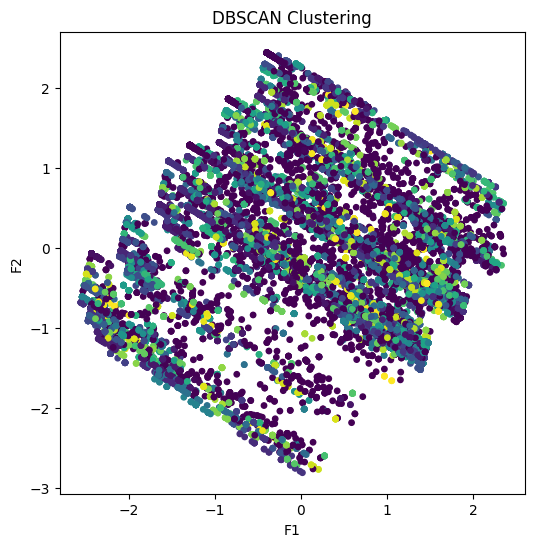

In [ ]:
# <Student to fill this section>
plt.figure(figsize=(6,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, s=15)
plt.xlabel('F1')
plt.ylabel('F2')
plt.title(f"DBSCAN Clustering")
plt.show()

In [ ]:
# <Student to fill this section>
business_impacts_explanations2 = """
DBSCAN can isolate outliers and discover natural groupings based on density, which is useful for identifying non-obvious segments.
This helps the Product Team detect niche segments or customers with unusual but valuable engagement profiles and avoid noise in campaigns.
Unlike KMeans, DBSCAN is not forced to group all customers, making it more precise in some use cases.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations2', value=business_impacts_explanations2)

## H. Project Outcomes

In [ ]:
# <Student to fill this section>
experiment_outcome = "Hypothesis Confirmed" # Either 'Hypothesis Confirmed', 'Hypothesis Partially Confirmed' or 'Hypothesis Rejected'

In [ ]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [ ]:
# <Student to fill this section>
experiment_results_explanations = """
Three clustering models were evaluated. DBSCAN outperformed KMeans and KMeans+PCA with a silhouette score of 0.514.
It also achieved the best Davies-Bouldin score, showing good separation between dense clusters.
KMeans with PCA was slightly better than baseline, confirming the benefit of dimensionality reduction.
DBSCAN also effectively isolated noise points, helping identify niche segments.
Overall, DBSCAN is recommended as the final model for customer segmentation and upsell targeting.
"""

In [ ]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)

36106-25AU-AT3-group<24>-<25934391>-clustering.ipynb